# Steps 7–9: Feature table, imbalanced classification, evaluation

**Task:** from a grid cell's past activity, predict whether the **next month** has an earthquake with M ≥ `MAJOR_MAG`.

| Part | Step | Output |
|---|---|---|
| 1 | Step 7: cell × month feature table + leakage checks | `data/processed/cell_month_features.csv`, `results/step7_*` |
| 2 | Step 8: models 0–5 (baseline, LogReg, LightGBM, class weight, SMOTE, tuned threshold) | `models/classifier.joblib`, `results/classification_metrics.csv`, `results/step8_*` |
| 3 | Step 9: evaluation of classification + summaries of Step 5 and Step 6 | `figures/step9_*`, `results/step9_*` |

Each part re-reads its inputs from disk, so Step 8 or 9 can be re-run without re-running the parts before it. Run time ≈ 3 minutes.

# Step 7: Feature table for classification (cell × month)

**Task:** using a grid cell's past earthquake activity, predict whether the
**next month** will have an earthquake with M ≥ `MAJOR_MAG` in that cell.

* One row = one `cell_id` × one calendar month `t`.
* Features use **only events in month `t` or earlier**.
* Target `y = 1` if month `t+1` has at least one `is_major` event in the cell.
* We never use per-event columns such as `nst`, `magType` or `magError`
  (they are computed together with the magnitude, so using them = leakage).

Output: `data/processed/cell_month_features.csv`, `results/step7_*.csv`,
`figures/step7_class_balance.png`.

In [1]:
import sys, json
from pathlib import Path
sys.path.append("../scripts")
import config as cfg

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(getattr(cfg, "ROOT", Path("..").resolve()))
CLEAN_FILE = Path(getattr(cfg, "CLEAN_FILE", ROOT / "data/processed/quakes_clean.csv"))
FEATURES_FILE = Path(getattr(cfg, "FEATURES_FILE", ROOT / "data/processed/cell_month_features.csv"))
RESULTS_DIR = Path(getattr(cfg, "RESULTS_DIR", ROOT / "results"))
FIGURES_DIR = Path(getattr(cfg, "FIGURES_DIR", ROOT / "figures"))
for p in (FEATURES_FILE.parent, RESULTS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

G = cfg.GRID_DEG
MAJOR_MAG = cfg.MAJOR_MAG
print("MAJOR_MAG =", MAJOR_MAG, "| GRID_DEG =", G, "| input:", CLEAN_FILE.name)

MAJOR_MAG = 6.5 | GRID_DEG = 5 | input: quakes_clean.csv


## 1. Load events
`is_major` is recomputed from `mag` with `MAJOR_MAG` so the label always
matches `config.py`, even if the threshold is changed later.

Longitude exactly 180° gives a cell like `-25_180`, which is the same place as
`-25_-180`. We merge those (2 events in the current file) so the grid wraps
cleanly at the date line.

In [2]:
ev = pd.read_csv(CLEAN_FILE, usecols=["id", "time", "depth", "depth_class", "mag", "cell_id"])
ev["time"] = pd.to_datetime(ev["time"], utc=True, format="ISO8601")
ev["is_major"] = (ev["mag"] >= MAJOR_MAG).astype(int)

ll = ev["cell_id"].str.split("_", expand=True).astype(int)
ev["cell_lat"], ev["cell_lon"] = ll[0], ll[1]
n_wrap = int((ev["cell_lon"] == 180).sum())
ev.loc[ev["cell_lon"] == 180, "cell_lon"] = -180
ev["cell_id"] = ev["cell_lat"].astype(str) + "_" + ev["cell_lon"].astype(str)

START = pd.Timestamp(cfg.START_DATE)
ev["m"] = (ev["time"].dt.year - START.year) * 12 + (ev["time"].dt.month - START.month)
print(f"{len(ev):,} events | {ev['cell_id'].nunique():,} cells | merged {n_wrap} events at lon=180")

187,547 events | 1,204 cells | merged 2 events at lon=180


## 2. Month range
The last month in the file is still in progress, so it cannot be used as a
target. Rows run from the first month up to the month **before** the last
complete month (its target is the last complete month).

In [3]:
data_end = ev["time"].max()
last_month_idx = int(ev["m"].max())          # month in progress (incomplete)
last_full_idx = last_month_idx - 1           # last complete month
n_months = last_month_idx + 1                # array width (include partial month for features only)
n_rows_months = last_full_idx                # rows t = 0 .. last_full_idx-1 (target t+1 <= last_full_idx)

def month_label(i):
    return (START + pd.DateOffset(months=int(i))).strftime("%Y-%m")

print("data ends:", data_end, "| last complete month:", month_label(last_full_idx))
print("feature rows: ", month_label(0), "to", month_label(n_rows_months - 1))

data ends: 2026-10-10 10:35:11.922000+00:00 | last complete month: 2026-09
feature rows:  2000-01 to 2026-08


## 3. Cell × month count arrays
Cells = every cell with at least one event (as the plan says). Each array is
`cells × months`.

In [4]:
cells = np.sort(ev["cell_id"].unique())
cidx = {c: i for i, c in enumerate(cells)}
ev["c"] = ev["cell_id"].map(cidx)
C, M = len(cells), n_months

def grid(values=None, how="sum"):
    a = np.zeros((C, M)) if how != "max" else np.full((C, M), np.nan)
    g = ev.groupby(["c", "m"])
    s = g.size() if values is None else getattr(g[values], how)()
    a[s.index.get_level_values(0), s.index.get_level_values(1)] = s.values
    return a

cnt = grid()                                   # events per cell-month
maj = grid("is_major")                         # major events per cell-month
mmax = grid("mag", "max")                      # max mag per cell-month (NaN = no event)
dsum = grid("depth")                           # sum of depth (for mean depth)
dcls = {k: np.zeros((C, M)) for k in ["shallow", "intermediate", "deep"]}
for k, s in ev.groupby(["depth_class", "c", "m"]).size().items():
    dcls[k[0]][k[1], k[2]] = s

def roll_sum(a, w):
    """Sum over months t-w+1 .. t (inclusive), per cell."""
    cs = np.cumsum(a, axis=1)
    out = cs.copy()
    out[:, w:] = cs[:, w:] - cs[:, :-w]
    return out

## 4. Features (all use months ≤ t)

| Feature | Meaning |
|---|---|
| `n_events_1m`, `n_events_3m`, `n_events_12m` | events in the cell in the last 1 / 3 / 12 months (incl. `t`) |
| `n_major_12m` | major events in the last 12 months (also used by the naive baseline) |
| `max_mag_12m` | largest magnitude in the last 12 months (0 if no event) |
| `months_since_major` | months since the last major in the cell, capped at 120 |
| `had_major_before` | 1 if the cell has had any major up to `t` |
| `n_events_hist` | all events in the cell from 2000 up to `t` |
| `mean_depth_hist` | mean depth (km) of all events up to `t` (0 if none yet) |
| `frac_shallow/intermediate/deep_hist` | share of each `depth_class` up to `t` |
| `nbr_events_1m`, `nbr_events_12m` | events in the 8 surrounding cells (longitude wraps at ±180) |
| `nbr_major_12m` | majors in the 8 surrounding cells, last 12 months |

History-based depth features use everything up to `t` instead of only 12
months, because most cells have no events in a given year.

In [5]:
F = {}
F["n_events_1m"] = cnt
F["n_events_3m"] = roll_sum(cnt, 3)
F["n_events_12m"] = roll_sum(cnt, 12)
F["n_major_12m"] = roll_sum(maj, 12)
F["max_mag_12m"] = (pd.DataFrame(mmax.T).rolling(12, min_periods=1).max()
                    .fillna(0).to_numpy().T)

# months since last major (cap 120); state carried forward month by month
CAP = 120
msm = np.full((C, M), CAP, dtype=float)
last = np.full(C, -10**6)
for t in range(M):
    last = np.where(maj[:, t] > 0, t, last)
    msm[:, t] = np.minimum(t - last, CAP)
F["months_since_major"] = msm
F["had_major_before"] = (np.cumsum(maj, axis=1) > 0).astype(float)

hist_n = np.cumsum(cnt, axis=1)
F["n_events_hist"] = hist_n
with np.errstate(invalid="ignore", divide="ignore"):
    F["mean_depth_hist"] = np.where(hist_n > 0, np.cumsum(dsum, axis=1) / hist_n, 0)
    for k in ["shallow", "intermediate", "deep"]:
        F[f"frac_{k}_hist"] = np.where(hist_n > 0, np.cumsum(dcls[k], axis=1) / hist_n, 0)

# neighbours: 8 surrounding cells, longitude wraps, latitude does not
lat_of = np.array([int(c.split("_")[0]) for c in cells])
lon_of = np.array([int(c.split("_")[1]) for c in cells])
def nbr_sum(a):
    out = np.zeros_like(a)
    for dlat in (-G, 0, G):
        for dlon in (-G, 0, G):
            if dlat == 0 and dlon == 0:
                continue
            nlon = (lon_of + dlon + 180) % 360 - 180
            keys = [f"{la}_{lo}" for la, lo in zip(lat_of + dlat, nlon)]
            j = np.array([cidx.get(k, -1) for k in keys])
            ok = j >= 0                      # missing neighbour = never had an event = 0
            out[ok] += a[j[ok]]
    return out

F["nbr_events_1m"] = nbr_sum(cnt)
F["nbr_events_12m"] = nbr_sum(F["n_events_12m"])
F["nbr_major_12m"] = nbr_sum(F["n_major_12m"])

## 5. Target and train / validation / test split
`y` at row `t` = any major in month `t+1`. The split uses the **target month**,
so no training label falls after `TRAIN_END`:

* train: target month ≤ `TRAIN_END` (2019-12)
* val:   target month ≤ `VAL_END` (2022-12)
* test:  later

In [6]:
y = np.zeros((C, M))
y[:, :-1] = (maj[:, 1:] > 0)

T = n_rows_months
cc, tt = np.meshgrid(np.arange(C), np.arange(T), indexing="ij")
tab = pd.DataFrame({
    "cell_id": cells[cc.ravel()],
    "cell_lat": lat_of[cc.ravel()],
    "cell_lon": lon_of[cc.ravel()],
    "month": [month_label(i) for i in tt.ravel()],
    "target_month": [month_label(i + 1) for i in tt.ravel()],
})
for k, a in F.items():
    tab[k] = a[:, :T].ravel()
tab["y"] = y[:, :T].ravel().astype(int)

tm = pd.to_datetime(tab["target_month"])
tab["split"] = np.where(tm <= pd.Timestamp(cfg.TRAIN_END), "train",
                np.where(tm <= pd.Timestamp(cfg.VAL_END), "val", "test"))

int_cols = ["n_events_1m", "n_events_3m", "n_events_12m", "n_major_12m",
            "months_since_major", "had_major_before", "n_events_hist",
            "nbr_events_1m", "nbr_events_12m", "nbr_major_12m"]
tab[int_cols] = tab[int_cols].astype(int)
for k in ["max_mag_12m", "mean_depth_hist", "frac_shallow_hist", "frac_intermediate_hist", "frac_deep_hist"]:
    tab[k] = tab[k].round(4)

tab = tab.sort_values(["month", "cell_id"]).reset_index(drop=True)
FEATURE_COLS = list(F.keys())
print(tab.shape)
tab.head()

(385280, 22)


,cell_id,cell_lat,cell_lon,month,target_month,n_events_1m,n_events_3m,n_events_12m,n_major_12m,max_mag_12m,...,n_events_hist,mean_depth_hist,frac_shallow_hist,frac_intermediate_hist,frac_deep_hist,nbr_events_1m,nbr_events_12m,nbr_major_12m,y,split
0,-10_-100,-10,-100,2000-01,2000-02,0,0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,0,0,0,0,train
1,-10_-105,-10,-105,2000-01,2000-02,0,0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,0,0,0,0,train
2,-10_-110,-10,-110,2000-01,2000-02,0,0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,0,0,0,0,train
3,-10_-115,-10,-115,2000-01,2000-02,0,0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,0,0,0,0,train
4,-10_-125,-10,-125,2000-01,2000-02,0,0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,0,0,0,0,train


## 6. Leakage checks
1. **Truncation test:** rebuild every feature using only events up to a cutoff
   month, then compare with the full table for rows at or before the cutoff.
   If any feature used future data, the values would differ.
2. **Target test:** `y` recomputed directly from the events of month `t+1`.
3. **Split test:** the latest train target month is ≤ `TRAIN_END`, and val/test
   don't overlap.
4. **Column test:** no per-event quality column is in the feature list.

In [7]:
def features_from(events, t_end):
    """Recompute features for rows month<=t_end from events with m<=t_end only."""
    e = events[events["m"] <= t_end]
    out = {}
    g = e.groupby(["c", "m"])
    a = np.zeros((C, t_end + 1)); s = g.size(); a[s.index.get_level_values(0), s.index.get_level_values(1)] = s.values
    jm = np.zeros((C, t_end + 1)); s = g["is_major"].sum(); jm[s.index.get_level_values(0), s.index.get_level_values(1)] = s.values
    out["n_events_12m"] = roll_sum(a, 12)
    out["n_major_12m"] = roll_sum(jm, 12)
    out["n_events_hist"] = np.cumsum(a, axis=1)
    out["nbr_events_12m"] = nbr_sum(out["n_events_12m"])
    return out

checks = []
for cutoff in ["2010-06", "2019-12", "2023-03"]:
    t_end = (int(cutoff[:4]) - START.year) * 12 + int(cutoff[5:7]) - START.month
    sub = features_from(ev, t_end)
    rows = tab[tab["month"] <= cutoff]
    ci = rows["cell_id"].map(cidx).to_numpy()
    ti = ((rows["month"].str[:4].astype(int) - START.year) * 12 + rows["month"].str[5:7].astype(int) - START.month).to_numpy()
    ok = all(np.array_equal(rows[k].to_numpy(), sub[k][ci, ti].astype(int)) for k in sub)
    checks.append({"check": f"truncation at {cutoff}: features unchanged without future data", "passed": ok})

# target recomputed from raw events
maj_ev = ev[ev["is_major"] == 1].assign(tm=lambda d: d["time"].dt.strftime("%Y-%m"))
pos = set(zip(maj_ev["cell_id"], maj_ev["tm"]))
y_check = np.array([(c, m) in pos for c, m in zip(tab["cell_id"], tab["target_month"])]).astype(int)
checks.append({"check": "y equals 'any major in target month' from raw events", "passed": bool((y_check == tab["y"]).all())})

checks.append({"check": f"latest train target month <= TRAIN_END ({cfg.TRAIN_END[:7]})",
               "passed": bool(tab.loc[tab.split == "train", "target_month"].max() <= cfg.TRAIN_END[:7])})
checks.append({"check": "val and test target months do not overlap",
               "passed": bool(tab.loc[tab.split == "val", "target_month"].max() < tab.loc[tab.split == "test", "target_month"].min())})
banned = {"nst", "gap", "rms", "dmin", "horizontalError", "depthError", "magError", "magNst", "magType", "mag", "y"}
checks.append({"check": "no per-event quality column or target in features", "passed": not (banned & set(FEATURE_COLS))})
checks.append({"check": "no missing values in feature table", "passed": bool(tab[FEATURE_COLS + ['y']].notna().all().all())})

checks = pd.DataFrame(checks)
checks.to_csv(RESULTS_DIR / "step7_leakage_checks.csv", index=False)
assert checks["passed"].all(), checks
checks

,check,passed
0,truncation at 2010-06: features unchanged with...,True
1,truncation at 2019-12: features unchanged with...,True
2,truncation at 2023-03: features unchanged with...,True
3,y equals 'any major in target month' from raw ...,True
4,latest train target month <= TRAIN_END (2019-12),True
5,val and test target months do not overlap,True
6,no per-event quality column or target in features,True
7,no missing values in feature table,True


## 7. Class imbalance (numbers for the slides)

In [8]:
order = ["train", "val", "test", "all"]
bal = (pd.concat([tab, tab.assign(split="all")])
       .groupby("split")
       .agg(rows=("y", "size"), positives=("y", "sum"),
            first_target_month=("target_month", "min"), last_target_month=("target_month", "max"))
       .reindex(order).reset_index())
bal["negatives"] = bal["rows"] - bal["positives"]
bal["pct_positive"] = (100 * bal["positives"] / bal["rows"]).round(3)
bal["neg_per_pos"] = (bal["negatives"] / bal["positives"]).round(1)
bal = bal[["split", "first_target_month", "last_target_month", "rows", "positives", "negatives", "pct_positive", "neg_per_pos"]]
bal.to_csv(RESULTS_DIR / "step7_class_balance.csv", index=False)

# naive baseline preview (model #0 in Step 8): predict 1 if a major happened in the last 12 months
base = tab.assign(pred=(tab["n_major_12m"] > 0).astype(int))
rows = []
for s in ["train", "val", "test"]:
    d = base[base.split == s]
    tp = int(((d.pred == 1) & (d.y == 1)).sum()); fp = int(((d.pred == 1) & (d.y == 0)).sum()); fn = int(((d.pred == 0) & (d.y == 1)).sum())
    p = tp / (tp + fp) if tp + fp else 0; r = tp / (tp + fn) if tp + fn else 0
    rows.append({"split": s, "precision": round(p, 4), "recall": round(r, 4),
                 "f1": round(2 * p * r / (p + r), 4) if p + r else 0, "tp": tp, "fp": fp, "fn": fn})
pd.DataFrame(rows).to_csv(RESULTS_DIR / "step7_baseline_preview.csv", index=False)

summary = pd.DataFrame([
    {"item": "cells", "value": C},
    {"item": "months", "value": T},
    {"item": "first_feature_month", "value": tab["month"].min()},
    {"item": "last_feature_month", "value": tab["month"].max()},
    {"item": "data_end_utc", "value": str(data_end)},
    {"item": "n_features", "value": len(FEATURE_COLS)},
    {"item": "events_merged_lon180", "value": n_wrap},
    {"item": "cells_first_active_after_TRAIN_END",
     "value": int((ev.groupby("cell_id")["time"].min() > pd.Timestamp(cfg.TRAIN_END, tz="UTC")).sum())},
])
summary.to_csv(RESULTS_DIR / "step7_table_summary.csv", index=False)
print(bal.to_string(index=False)); print(); print(pd.DataFrame(rows).to_string(index=False))

split first_target_month last_target_month   rows  positives  negatives  pct_positive  neg_per_pos
train            2000-02           2019-12 287756        810     286946         0.281        354.3
  val            2020-01           2022-12  43344        102      43242         0.235        423.9
 test            2023-01           2026-09  54180        134      54046         0.247        403.3
  all            2000-02           2026-09 385280       1046     384234         0.271        367.3

split  precision  recall     f1  tp   fp  fn
train     0.0298  0.2914 0.0541 236 7682 574
  val     0.0229  0.2353 0.0418  24 1022  78
 test     0.0235  0.2388 0.0428  32 1330 102


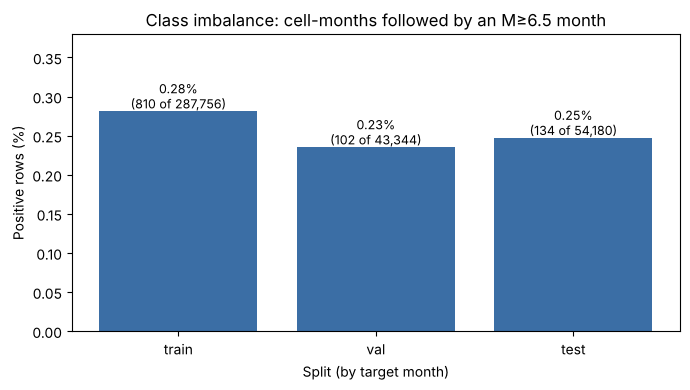

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
b = bal[bal.split != "all"]
ax.bar(b["split"], b["pct_positive"], color="#3b6ea5")
for x, v, n in zip(b["split"], b["pct_positive"], b["positives"]):
    ax.text(x, v, f"{v:.2f}%\n({n:,} of {int(b.loc[b.split == x, 'rows'].iloc[0]):,})", ha="center", va="bottom", fontsize=9)
ax.set_title(f"Class imbalance: cell-months followed by an M≥{MAJOR_MAG} month")
ax.set_xlabel("Split (by target month)")
ax.set_ylabel("Positive rows (%)")
ax.set_ylim(0, b["pct_positive"].max() * 1.35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "step7_class_balance.png", dpi=cfg.FIG_DPI)
plt.show()

## 8. Save

In [10]:
tab.to_csv(FEATURES_FILE, index=False)
(RESULTS_DIR / "step7_feature_columns.json").write_text(json.dumps(FEATURE_COLS, indent=1))
print("saved", FEATURES_FILE, f"({len(tab):,} rows, {len(FEATURE_COLS)} features)")

saved /home/claude/proj/quake-project/data/processed/cell_month_features.csv (385,280 rows, 15 features)


# Step 8: Imbalanced classification

This part reads only `cell_month_features.csv`, so it can be run on its own.

* **Split by time** using the `split` column from Step 7 (train: target ≤ 2019,
  val: 2020–2022, test: 2023+). There is no random `train_test_split`.
* Every scaler and SMOTE is fitted **on train only**, inside a pipeline.
* Val is used for choosing the best model and its threshold. Test is used only
  once, at the end, to report results.

| # | Model | Imbalance handling |
|---|---|---|
| 0 | Naive baseline: predict 1 if the cell had a major in the last 12 months | none |
| 1 | Logistic Regression | none |
| 2 | Logistic Regression | `class_weight="balanced"` |
| 3 | LightGBM | class weight (`class_weight="balanced"`) |
| 4 | LightGBM | SMOTE on train |
| 5 | Best of 1–4 by val PR-AUC | threshold tuned on val (max F1) |

In [11]:
import sys, json, warnings
from pathlib import Path
sys.path.append("../scripts")
import config as cfg

import numpy as np
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score, confusion_matrix,
                             precision_recall_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path(getattr(cfg, "ROOT", Path("..").resolve()))
FEATURES_FILE = Path(getattr(cfg, "FEATURES_FILE", ROOT / "data/processed/cell_month_features.csv"))
RESULTS_DIR = Path(getattr(cfg, "RESULTS_DIR", ROOT / "results"))
MODELS_DIR = Path(getattr(cfg, "MODELS_DIR", ROOT / "models"))
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RS = cfg.RANDOM_STATE

tab = pd.read_csv(FEATURES_FILE)
FEATURE_COLS = json.loads((RESULTS_DIR / "step7_feature_columns.json").read_text())
parts = {s: tab[tab["split"] == s] for s in ["train", "val", "test"]}
X = {s: d[FEATURE_COLS] for s, d in parts.items()}
y = {s: d["y"].to_numpy() for s, d in parts.items()}
for s in parts:
    print(f"{s:5}  rows={len(y[s]):>7,}  positives={y[s].sum():>4}  ({100*y[s].mean():.3f}%)")

train  rows=287,756  positives= 810  (0.281%)
val    rows= 43,344  positives= 102  (0.235%)
test   rows= 54,180  positives= 134  (0.247%)


## Preprocessing for Logistic Regression
The count features are very skewed (most months 0, Tōhoku month 1,889), so for
Logistic Regression they are `log1p`-transformed and then standardised. Trees
(LightGBM) don't need this, so they get the raw features.

In [12]:
COUNT_COLS = [c for c in FEATURE_COLS if c.startswith(("n_", "nbr_")) or c == "months_since_major"]
OTHER_COLS = [c for c in FEATURE_COLS if c not in COUNT_COLS]

def lr_prep():
    return ColumnTransformer([
        ("counts", Pipeline([("log", FunctionTransformer(np.log1p)), ("sc", StandardScaler())]), COUNT_COLS),
        ("other", StandardScaler(), OTHER_COLS),
    ])

LGBM_PARAMS = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=100,
                   subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                   random_state=RS, n_jobs=-1, verbose=-1)

models = {
    "1_logreg_none": Pipeline([("prep", lr_prep()),
                               ("clf", LogisticRegression(max_iter=2000))]),
    "2_logreg_class_weight": Pipeline([("prep", lr_prep()),
                                       ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "3_lgbm_class_weight": LGBMClassifier(class_weight="balanced", **LGBM_PARAMS),
    # SMOTE to 10% minority: 810 real positives -> ~28,700. Oversampling to 50/50
    # would mean ~350 synthetic points per real one, mostly interpolated noise.
    "4_lgbm_smote": ImbPipeline([("smote", SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=RS)),
                                 ("clf", LGBMClassifier(**LGBM_PARAMS))]),
}

## Train (on train only) and score val + test

In [13]:
scores = {}   # model -> {split: probability-like score}
scores["0_naive_baseline"] = {s: parts[s]["n_major_12m"].to_numpy().astype(float) for s in ["val", "test"]}
thresholds = {"0_naive_baseline": 1.0}   # predict 1 when n_major_12m >= 1

for name, m in models.items():
    m.fit(X["train"], y["train"])
    scores[name] = {s: m.predict_proba(X[s])[:, 1] for s in ["val", "test"]}
    thresholds[name] = 0.5
    print("trained", name)

def metrics(y_true, score, thr):
    pred = (score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"threshold": round(float(thr), 4),
            "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "pr_auc": average_precision_score(y_true, score),
            "roc_auc": roc_auc_score(y_true, score),
            "predicted_pos": int(pred.sum()), "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)}

trained 1_logreg_none


trained 2_logreg_class_weight


trained 3_lgbm_class_weight


trained 4_lgbm_smote


## Model 5: best model + threshold tuned on val
Pick the model with the highest **val PR-AUC** among 1–4, then choose the
threshold that maximises **val F1**. Test is not looked at for either choice.

In [14]:
val_prauc = {n: average_precision_score(y["val"], scores[n]["val"]) for n in models}
best_name = max(val_prauc, key=val_prauc.get)

p, r, t = precision_recall_curve(y["val"], scores[best_name]["val"])
f1s = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
best_thr = float(t[np.nanargmax(f1s)])

scores["5_best_tuned_threshold"] = scores[best_name]
thresholds["5_best_tuned_threshold"] = best_thr
print("val PR-AUC:", {k: round(v, 4) for k, v in val_prauc.items()})
print(f"best = {best_name}, tuned threshold = {best_thr:.4f}")

val PR-AUC: {'1_logreg_none': 0.0301, '2_logreg_class_weight': 0.0309, '3_lgbm_class_weight': 0.0276, '4_lgbm_smote': 0.0228}
best = 2_logreg_class_weight, tuned threshold = 0.9720


## Results table

In [15]:
labels = {
    "0_naive_baseline": ("Naive baseline (major in last 12 months)", "none"),
    "1_logreg_none": ("Logistic Regression", "none"),
    "2_logreg_class_weight": ("Logistic Regression", "class_weight=balanced"),
    "3_lgbm_class_weight": ("LightGBM", "class_weight=balanced"),
    "4_lgbm_smote": ("LightGBM", "SMOTE (train only, 10%)"),
    "5_best_tuned_threshold": (f"Best = {best_name}", "threshold tuned on val"),
}
rows = []
for name in labels:
    for s in ["val", "test"]:
        rows.append({"model_id": name, "model": labels[name][0], "imbalance": labels[name][1],
                     "split": s, **metrics(y[s], scores[name][s], thresholds[name])})
res = pd.DataFrame(rows)
num = ["accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc"]
res[num] = res[num].round(4)
res.to_csv(RESULTS_DIR / "classification_metrics.csv", index=False)

# share of positives = PR-AUC of a random guess (reference line for Step 9)
pd.DataFrame([{"split": s, "positive_rate": round(float(y[s].mean()), 5)} for s in ["val", "test"]]) \
  .to_csv(RESULTS_DIR / "step8_random_prauc.csv", index=False)

show = ["model_id", "split", "threshold", "accuracy", "precision", "recall", "f1", "pr_auc", "predicted_pos", "tp", "fp", "fn"]
print(res[show].to_string(index=False))

              model_id split  threshold  accuracy  precision  recall     f1  pr_auc  predicted_pos  tp    fp  fn
      0_naive_baseline   val      1.000    0.9746     0.0229  0.2353 0.0418  0.0112           1046  24  1022  78
      0_naive_baseline  test      1.000    0.9736     0.0235  0.2388 0.0428  0.0119           1362  32  1330 102
         1_logreg_none   val      0.500    0.9976     0.0000  0.0000 0.0000  0.0301              0   0     0 102
         1_logreg_none  test      0.500    0.9975     0.0000  0.0000 0.0000  0.0432              0   0     0 134
 2_logreg_class_weight   val      0.500    0.8035     0.0105  0.8824 0.0207  0.0309           8597  90  8507  12
 2_logreg_class_weight  test      0.500    0.8045     0.0109  0.8731 0.0216  0.0405          10694 117 10577  17
   3_lgbm_class_weight   val      0.500    0.8895     0.0153  0.7255 0.0300  0.0276           4837  74  4763  28
   3_lgbm_class_weight  test      0.500    0.8953     0.0178  0.7612 0.0347  0.0363           57

## Save the best model and the scores for Step 9
`models/classifier.joblib` holds the fitted model, the threshold and the
feature list. `results/step8_predictions.csv` holds every model's val/test
score so Step 9 can draw PR curves and confusion matrices without retraining.

In [16]:
joblib.dump({"model": models[best_name], "model_id": best_name, "threshold": best_thr,
             "features": FEATURE_COLS, "major_mag": cfg.MAJOR_MAG,
             "trained_on": "split == 'train' (target month <= TRAIN_END)"},
            MODELS_DIR / "classifier.joblib")

pred = pd.concat([parts[s][["cell_id", "month", "target_month", "split", "y"]] for s in ["val", "test"]])
for name in labels:
    pred[name] = np.concatenate([scores[name]["val"], scores[name]["test"]])
pred.round(6).to_csv(RESULTS_DIR / "step8_predictions.csv", index=False)
(RESULTS_DIR / "step8_thresholds.json").write_text(json.dumps(thresholds, indent=1))
print("saved models/classifier.joblib and results/step8_predictions.csv")

saved models/classifier.joblib and results/step8_predictions.csv


# Step 9: Evaluation

Uses only files saved by Step 8 (`results/classification_metrics.csv`,
`results/step8_predictions.csv`, `models/classifier.joblib`), so nothing is retrained.

1. Classification: accuracy vs the real metrics, PR curves, confusion matrix,
   feature importance, and a bootstrap test against the naive baseline.
2. Anomaly (Step 6) and clustering (Step 5): summarised from B's result files.
3. Conclusions for all three techniques (`results/step9_conclusions.md`).

In [17]:
import sys, json
from pathlib import Path
sys.path.append("../scripts")
import config as cfg

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance

ROOT = Path(getattr(cfg, "ROOT", Path("..").resolve()))
RESULTS_DIR = Path(getattr(cfg, "RESULTS_DIR", ROOT / "results"))
FIGURES_DIR = Path(getattr(cfg, "FIGURES_DIR", ROOT / "figures"))
MODELS_DIR = Path(getattr(cfg, "MODELS_DIR", ROOT / "models"))
FEATURES_FILE = Path(getattr(cfg, "FEATURES_FILE", ROOT / "data/processed/cell_month_features.csv"))

res = pd.read_csv(RESULTS_DIR / "classification_metrics.csv")
pred = pd.read_csv(RESULTS_DIR / "step8_predictions.csv")
thr = json.loads((RESULTS_DIR / "step8_thresholds.json").read_text())
best = joblib.load(MODELS_DIR / "classifier.joblib")
test = pred[pred.split == "test"].reset_index(drop=True)

# shared figure style (light, recessive axes; matches the project palette)
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({"figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
                     "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "font.size": 10})

## 1. Accuracy is not a useful metric here
With 0.25% positives, a model that always says "no major" gets 99.75% accuracy.
Model 1 does exactly that. The table compares accuracy with the metrics that
actually measure the minority class.

In [18]:
cols = ["model_id", "threshold", "accuracy", "precision", "recall", "f1", "pr_auc", "predicted_pos", "tp", "fp", "fn"]
res[res.split == "test"][cols]

,model_id,threshold,accuracy,precision,recall,f1,pr_auc,predicted_pos,tp,fp,fn
1,0_naive_baseline,1.000,0.9736,0.0235,0.2388,0.0428,0.0119,1362,32,1330,102
3,1_logreg_none,0.500,0.9975,0.0000,0.0000,0.0000,0.0432,0,0,0,134
5,2_logreg_class_weight,0.500,0.8045,0.0109,0.8731,0.0216,0.0405,10694,117,10577,17
7,3_lgbm_class_weight,0.500,0.8953,0.0178,0.7612,0.0347,0.0363,5742,102,5640,32
9,4_lgbm_smote,0.500,0.9951,0.0288,0.0299,0.0293,0.0265,139,4,135,130
11,5_best_tuned_threshold,0.972,0.9919,0.0551,0.1418,0.0793,0.0405,345,19,326,115


## 2. Precision-recall curves (test)
Models 2 and 5 are the same model (5 only changes the threshold), so they share
one curve; the dots mark where each model operates at its threshold.
The dashed line is a random guess (PR-AUC = share of positives).

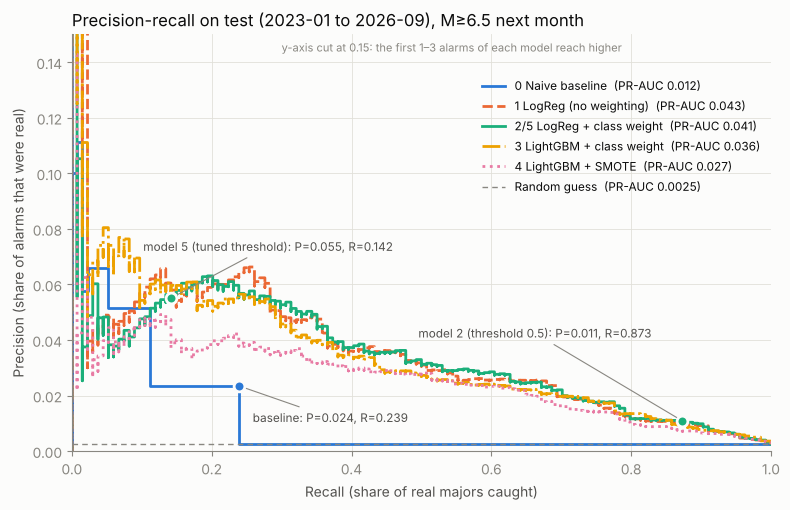

In [19]:
curves = [("0_naive_baseline", "0 Naive baseline"), ("1_logreg_none", "1 LogReg (no weighting)"),
          ("2_logreg_class_weight", "2/5 LogReg + class weight"), ("3_lgbm_class_weight", "3 LightGBM + class weight"),
          ("4_lgbm_smote", "4 LightGBM + SMOTE")]
styles = ["-", "--", "-", "-.", ":"]
yt = test["y"].to_numpy()
base_rate = yt.mean()

fig, ax = plt.subplots(figsize=(8, 5.2))
for (mid, lab), col, ls in zip(curves, SERIES, styles):
    p, r, _ = precision_recall_curve(yt, test[mid])
    ax.plot(r, p, color=col, lw=2, ls=ls, label=f"{lab}  (PR-AUC {average_precision_score(yt, test[mid]):.3f})",
            drawstyle="steps-post")
ax.axhline(base_rate, color=MUTED, lw=1, ls=(0, (4, 3)), label=f"Random guess  (PR-AUC {base_rate:.4f})")

# operating points (label offsets chosen so the labels don't collide)
for mid, col, txt, off in [("0_naive_baseline", SERIES[0], "baseline", (10, -26)),
                           ("5_best_tuned_threshold", SERIES[2], "model 5 (tuned threshold)", (-20, 34)),
                           ("2_logreg_class_weight", SERIES[2], "model 2 (threshold 0.5)", (-190, 60))]:
    row = res[(res.model_id == mid) & (res.split == "test")].iloc[0]
    ax.scatter(row.recall, row.precision, s=60, color=col, edgecolor=SURF, linewidth=2, zorder=5)
    ax.annotate(f"{txt}: P={row.precision:.3f}, R={row.recall:.3f}", (row.recall, row.precision),
                xytext=off, textcoords="offset points", fontsize=8.5, color=INK2,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
YMAX = 0.15
ax.set_xlim(0, 1); ax.set_ylim(0, YMAX)
ax.text(0.30, YMAX * 0.985, "y-axis cut at 0.15: the first 1–3 alarms of each model reach higher", fontsize=8, color=MUTED, va="top")
ax.set_xlabel("Recall (share of real majors caught)")
ax.set_ylabel("Precision (share of alarms that were real)")
ax.set_title(f"Precision-recall on test (2023-01 to {test.target_month.max()}), M≥{cfg.MAJOR_MAG} next month", loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(1, 0.92))
fig.tight_layout(); fig.savefig(FIGURES_DIR / "step9_pr.png", dpi=cfg.FIG_DPI); plt.show()

## 3. Confusion matrices (test): baseline vs best model

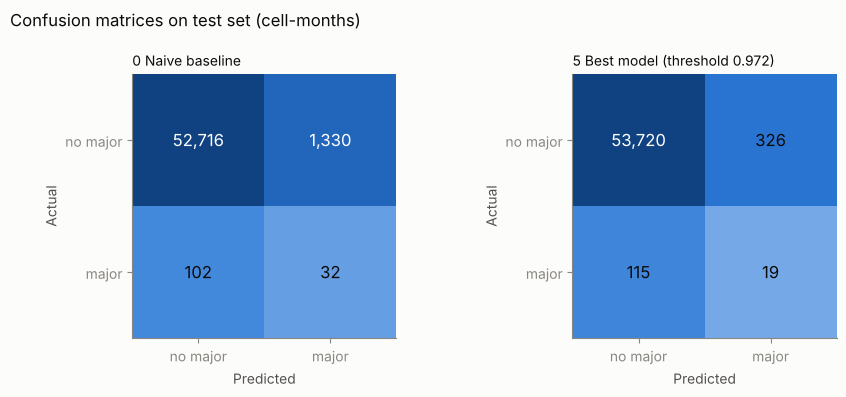

In [20]:
blues = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#104281"])
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (mid, title) in zip(axes, [("0_naive_baseline", "0 Naive baseline"),
                                   ("5_best_tuned_threshold", f"5 Best model (threshold {thr['5_best_tuned_threshold']:.3f})")]):
    cm = confusion_matrix(yt, (test[mid] >= thr[mid]).astype(int), labels=[0, 1])
    ax.imshow(cm, cmap=blues, norm=LogNorm(vmin=1, vmax=cm.max()))
    for (i, j), v in np.ndenumerate(cm):
        dark = np.log(max(v, 1)) / np.log(cm.max()) > 0.55
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=12, color="white" if dark else INK)
    ax.set_xticks([0, 1], ["no major", "major"]); ax.set_yticks([0, 1], ["no major", "major"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.grid(False)
    ax.set_title(title, loc="left", fontsize=10)
fig.suptitle("Confusion matrices on test set (cell-months)", x=0.02, ha="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "step9_cm.png", dpi=cfg.FIG_DPI); plt.show()

## 4. Feature importance (best model)
**Permutation importance on validation:** shuffle one feature at a time and
measure how much PR-AUC drops. It works for any model type and is measured on
data the model wasn't trained on. Test isn't used. Validation has only ~100
positives, so the values are noisy: read the top few as the signal, and treat
bars whose error bar crosses 0 as no clear effect.

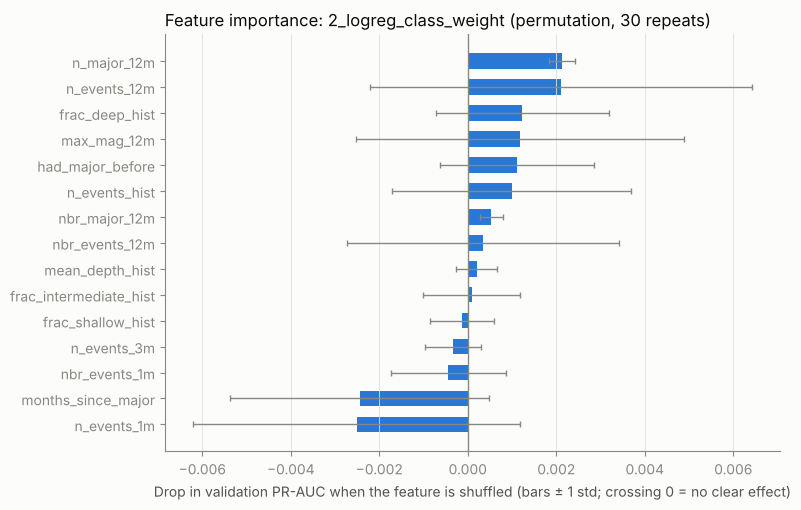

,feature,pr_auc_drop,std
3,n_major_12m,0.002125,0.000292
2,n_events_12m,0.002104,0.004320
11,frac_deep_hist,0.001229,0.001951
4,max_mag_12m,0.001184,0.003711
6,had_major_before,0.001111,0.001749
7,n_events_hist,0.000994,0.002704
14,nbr_major_12m,0.000532,0.000259
13,nbr_events_12m,0.000344,0.003070


In [21]:
tab = pd.read_csv(FEATURES_FILE)
val = tab[tab.split == "val"]
y_val_pos = int(val["y"].sum())
pi = permutation_importance(best["model"], val[best["features"]], val["y"], scoring="average_precision",
                            n_repeats=30, random_state=cfg.RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({"feature": best["features"], "pr_auc_drop": pi.importances_mean, "std": pi.importances_std})
       .sort_values("pr_auc_drop", ascending=False))
imp.round(5).to_csv(RESULTS_DIR / "step9_feature_importance.csv", index=False)

d = imp.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(d.feature, d.pr_auc_drop, xerr=d["std"], color=SERIES[0], height=0.6,
        error_kw=dict(ecolor=MUTED, lw=1, capsize=2))
ax.axvline(0, color=MUTED, lw=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Drop in validation PR-AUC when the feature is shuffled (bars ± 1 std; crossing 0 = no clear effect)")
ax.set_title(f"Feature importance: {best['model_id']} (permutation, 30 repeats)", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "step9_importance.png", dpi=cfg.FIG_DPI); plt.show()
imp.head(8)

## 5. Does the best model really beat the baseline? (bootstrap)
Test has only 134 positive cell-months, so the scores could move by chance.
We resample **whole target months** (rows in the same month are related) 2,000
times and recompute the difference each time.

In [22]:
months = test.target_month.unique()
idx_by_m = {m: np.where(test.target_month == m)[0] for m in months}
rng = np.random.default_rng(cfg.RANDOM_STATE)
b_pred = (test["0_naive_baseline"] >= thr["0_naive_baseline"]).astype(int).to_numpy()
m_pred = (test["5_best_tuned_threshold"] >= thr["5_best_tuned_threshold"]).astype(int).to_numpy()
diffs = {"f1": [], "pr_auc": []}
for _ in range(2000):
    ii = np.concatenate([idx_by_m[m] for m in rng.choice(months, len(months))])
    diffs["f1"].append(f1_score(yt[ii], m_pred[ii]) - f1_score(yt[ii], b_pred[ii]))
    diffs["pr_auc"].append(average_precision_score(yt[ii], test["5_best_tuned_threshold"].to_numpy()[ii])
                           - average_precision_score(yt[ii], test["0_naive_baseline"].to_numpy()[ii]))
boot = pd.DataFrame([{"metric": k, "model5_minus_baseline_mean": np.mean(v),
                      "ci95_low": np.percentile(v, 2.5), "ci95_high": np.percentile(v, 97.5),
                      "share_of_resamples_baseline_wins_or_ties": np.mean(np.array(v) <= 0)}
                     for k, v in diffs.items()]).round(4)
boot.to_csv(RESULTS_DIR / "step9_bootstrap.csv", index=False)
boot

,metric,model5_minus_baseline_mean,ci95_low,ci95_high,share_of_resamples_baseline_wins_or_ties
0,f1,0.0366,0.0131,0.0608,0.0005
1,pr_auc,0.0286,0.0100,0.0516,0.0015


## 6. Anomaly detection (Step 6)
From `results/anomaly_metrics.csv` (B's notebook `05_anomaly.ipynb`). A cell-week
counts as a true anomaly if it contains an M ≥ 7.0 event. The rows below are the
contamination chosen on validation for each feature set:

* **A: with max magnitude.** This feature is computed from the same values as
  the answer, so its score is optimistic. It is reported only to show that.
* **B: without max magnitude.** This is the honest result.
* **C: activity only.**

In [23]:
an = pd.read_csv(RESULTS_DIR / "anomaly_metrics.csv")
an_sel = an[an["chosen"].astype(str).str.lower() == "true"]
an_cols = ["split", "feature_set", "contamination", "flagged", "true_positives", "precision", "recall", "f1",
           "pr_auc", "random_precision", "lift_vs_random"]
an_sel = an_sel[an_cols].sort_values(["feature_set", "split"], ascending=[True, False])
an_sel.to_csv(RESULTS_DIR / "step9_anomaly_summary.csv", index=False)
an_sel

,split,feature_set,contamination,flagged,true_positives,precision,recall,f1,pr_auc,random_precision,lift_vs_random
1,val,A: with max magnitude,0.002,15,12,0.800,0.324,0.462,0.506,0.0033,241.8
19,test,A: with max magnitude,0.002,29,22,0.759,0.407,0.530,0.601,0.0040,190.3
7,val,B: without max magnitude,0.002,16,7,0.438,0.189,0.264,0.205,0.0033,132.2
25,test,B: without max magnitude,0.002,33,14,0.424,0.259,0.322,0.274,0.0040,106.4
13,val,C: activity only,0.002,17,6,0.353,0.162,0.222,0.156,0.0033,106.7
31,test,C: activity only,0.002,33,16,0.485,0.296,0.368,0.244,0.0040,121.6


## 7. Clustering (Step 5)
From `results/step5_facts.csv`, `clusters_summary.csv` and
`step5_known_events_check.csv` (B's notebook `04_clustering.ipynb`).
Clustering has no labels, so it is checked against the 5 known events from Step 4.

In [24]:
facts = pd.read_csv(RESULTS_DIR / "step5_facts.csv").set_index("item")["value"]
known = pd.read_csv(RESULTS_DIR / "step5_known_events_check.csv")
keep = ["chosen eps1 (km)", "chosen eps2 (days)", "chosen min_samples", "clusters", "noise pct",
        "aftershock sequences", "swarms", "clusters with >= 10 events",
        "major earthquakes inside a cluster pct", "known events inside a cluster",
        "mean aftershock capture of known events", "cluster rank 1", "cluster rank 2", "cluster rank 3"]
cl_sum = facts.reindex(keep).rename_axis("item").reset_index()
cl_sum.to_csv(RESULTS_DIR / "step9_clustering_summary.csv", index=False)
display(cl_sum)
known

,item,value
0,chosen eps1 (km),100
1,chosen eps2 (days),7
2,chosen min_samples,5
3,clusters,3567
4,noise pct,66.5
5,aftershock sequences,1991
6,swarms,1576
7,clusters with >= 10 events,1127
8,major earthquakes inside a cluster pct,63.4
9,known events inside a cluster,5 of 5


,event,mag,in_cluster,cluster_rank,cluster_events,cluster_days,followers_30d_300km,capture
0,Sumatra 2004,9.1,True,2,2326,273.6,278,0.98
1,Tohoku 2011,9.1,True,1,2980,215.0,1910,1.00
2,Turkey 2023,7.8,True,49,154,18.8,169,0.91
3,Myanmar 2025,7.7,True,448,20,13.9,22,0.82
4,Kamchatka 2025,8.8,True,3,1681,142.2,834,1.00


## 8. Conclusions (numbers read from `results/`)

In [25]:
t = res[res.split == "test"].set_index("model_id")
b, m5, m1 = t.loc["0_naive_baseline"], t.loc["5_best_tuned_threshold"], t.loc["1_logreg_none"]
bf, bp = boot.set_index("metric").loc["f1"], boot.set_index("metric").loc["pr_auc"]
clear = ", ".join(imp.loc[imp.pr_auc_drop - imp["std"] > 0, "feature"])  # error bar stays above 0

cls = [
    f"1. Accuracy is misleading: Logistic Regression without imbalance handling scores {m1.accuracy:.1%} accuracy but catches {int(m1.tp)} of {int(m1.tp + m1.fn)} majors (F1 = 0).",
    f"2. Best model: {best['model_id']} with a threshold tuned on validation ({best['threshold']:.3f}). On test: precision {m5.precision:.3f}, recall {m5.recall:.3f}, F1 {m5.f1:.3f}, PR-AUC {m5.pr_auc:.3f}.",
    f"3. It beats the naive baseline (F1 {b.f1:.3f}, PR-AUC {b.pr_auc:.3f}): F1 +{bf.model5_minus_baseline_mean:.3f} (95% CI {bf.ci95_low:+.3f} to {bf.ci95_high:+.3f}), PR-AUC +{bp.model5_minus_baseline_mean:.3f} (95% CI {bp.ci95_low:+.3f} to {bp.ci95_high:+.3f}); the baseline wins in {bf.share_of_resamples_baseline_wins_or_ties:.2%} of resamples.",
    f"4. PR-AUC {m5.pr_auc:.3f} is {m5.pr_auc / base_rate:.0f}x a random guess ({base_rate:.4f}), but {int(m5.fp)} of {int(m5.predicted_pos)} alarms are false and {int(m5.fn)} of {int(m5.tp + m5.fn)} majors are missed: useful for ranking risky cells, not as a warning system.",
    f"5. Feature importance is noisy (only {int(y_val_pos)} validation positives); the features with a clear effect are {clear}, i.e. recent major activity in the cell and its neighbours. "
    f"Class weighting helped Logistic Regression more than LightGBM; SMOTE did not help. LightGBM was not tuned, so this comparison is indicative only.",
]

ta = an_sel[an_sel.split == "test"].set_index("feature_set")
A = ta[ta.index.str.startswith("A")].iloc[0]; B = ta[ta.index.str.startswith("B")].iloc[0]
ano = [
    f"1. Honest result (set B, without max magnitude), test: precision {B.precision:.3f}, recall {B.recall:.3f}, F1 {B.f1:.3f}, PR-AUC {B.pr_auc:.3f}, {B.lift_vs_random:.0f}x better precision than random ({B.random_precision:.3f}).",
    f"2. With max magnitude (set A) the test scores rise to precision {A.precision:.3f}, recall {A.recall:.3f}, PR-AUC {A.pr_auc:.3f}. That gap is the leakage effect: the feature is computed from the same values as the answer.",
]

clu = [
    f"1. Chosen ST-DBSCAN settings: eps1 = {facts['chosen eps1 (km)']} km, eps2 = {facts['chosen eps2 (days)']} days, min_samples = {facts['chosen min_samples']}; {int(float(facts['clusters'])):,} clusters, {facts['noise pct']}% of events are noise.",
    f"2. Checked against real events: {facts['known events inside a cluster']} known events fall inside a cluster (mean aftershock capture {facts['mean aftershock capture of known events']}); the 3 largest clusters are {facts['cluster rank 1'].split(', ')[1]}, {facts['cluster rank 2'].split(', ')[1]} and {facts['cluster rank 3'].split(', ')[1]}.",
]

text = ("# Step 9 conclusions\n\n## Classification (Steps 7-8)\n\n" + "\n".join(cls) +
        "\n\n## Anomaly detection (Step 6)\n\n" + "\n".join(ano) +
        "\n\n## Clustering (Step 5)\n\n" + "\n".join(clu) + "\n")
(RESULTS_DIR / "step9_conclusions.md").write_text(text)
print(text)

# Step 9 conclusions

## Classification (Steps 7-8)

1. Accuracy is misleading: Logistic Regression without imbalance handling scores 99.8% accuracy but catches 0 of 134 majors (F1 = 0).
2. Best model: 2_logreg_class_weight with a threshold tuned on validation (0.972). On test: precision 0.055, recall 0.142, F1 0.079, PR-AUC 0.041.
3. It beats the naive baseline (F1 0.043, PR-AUC 0.012): F1 +0.037 (95% CI +0.013 to +0.061), PR-AUC +0.029 (95% CI +0.010 to +0.052); the baseline wins in 0.05% of resamples.
4. PR-AUC 0.041 is 16x a random guess (0.0025), but 326 of 345 alarms are false and 115 of 134 majors are missed: useful for ranking risky cells, not as a warning system.
5. Feature importance is noisy (only 102 validation positives); the features with a clear effect are n_major_12m, nbr_major_12m, i.e. recent major activity in the cell and its neighbours. Class weighting helped Logistic Regression more than LightGBM; SMOTE did not help. LightGBM was not tuned, so this comparison is in